# m-mode solving of a simulated drift scan

`limTOD.TODSim` simulates a zenith-pointing horn at Jodrell Bank drifting through one sidereal day;
`limTOD.mmode` solves the time-ordered data for the m-mode spectra

$$d(\nu,t)=\sum_m d_m(\nu)\,e^{im(t-t_{\rm ref})},\qquad
d(t)=d_0+2\sum_{m\ge1}\big[\mathrm{Re}\,d_m\cos m\Delta t-\mathrm{Im}\,d_m\sin m\Delta t\big],$$

following Zhang, *M-mode RIME explicit in beam, fringe and sky modes*
([note](https://zh-zhang.com/myNotes/MmodeNote.pdf), eqns 13–14) with the fringe set to unity.
The interactive companion — the RHINO beam's $B_{\ell m}$, the sky's $T_{\ell m}$, the resulting $d_m(\nu)$,
the LST-smoothing filter and the solvability-versus-coverage study this solver was designed from — is the
**[RHINO Drift-Scan m-Modes explorer](https://claude.ai/artifact/7Ra9SBXBtvLMA27o9t3Z6T)** (private link).

The notebook walks through what the solver can and cannot do:

1. a **closed scan** solves every mode exactly and the noise propagates as advertised;
2. a **7 h arc** cannot separate the low modes, and the error budget says so;
3. **stacking nights** closes the circle;
4. **LST smoothing** suppresses the modes above a truncation on a partial arc;
5. **bayesmith** gives exact posterior samples instead of truncating.

Sizes are kept small (N$_{\rm side}$ = 32, seven channels, 240 s cadence); the simulation is about four minutes.

In [1]:
import os, warnings, time
os.environ["TQDM_DISABLE"] = "1"          # limTOD's per-sample progress bars
import numpy as np
import matplotlib.pyplot as plt

from limTOD import TODSim, GDSM_sky_model, example_symm_beam_map
from limTOD import mmode

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
FREQS = np.arange(55.0, 86.0, 5.0)         # MHz, seven channels
NSIDE = 32
JBO = dict(ant_latitude_deg=53.23625, ant_longitude_deg=-2.30744, ant_height_m=80.0)
COLORS = plt.cm.viridis(np.linspace(0, 0.9, FREQS.size))

## 1. Simulate a closed drift scan

A 30° FWHM Gaussian beam stands in for the horn. The scan is one full sidereal day at a cadence chosen so the
last sample lands exactly one cadence before the first: `LSTWindow` then recognises it as **closed**, which is
what makes the modes orthogonal.

In [2]:
sim = TODSim(**JBO,
             beam_func=lambda freq, nside: example_symm_beam_map(freq=freq, nside=nside, FWHM=30.0),
             sky_func=GDSM_sky_model, beam_nside=NSIDE, sky_nside=NSIDE)

SIDEREAL_DAY = 86164.0905                 # s
N_T = 359                                 # samples: 240 s cadence, closes the circle
t_list = np.arange(N_T) * SIDEREAL_DAY / N_T

t0 = time.time()
tod_sky, lst = sim.simulate_sky_TOD(FREQS, t_list, np.zeros(N_T), 90.0, return_LSTs=True)
tod_sky = tod_sky.T                       # (n_time, n_freq), the layout mmode expects
print(f"simulated {tod_sky.shape} in {time.time()-t0:.0f} s")

window = mmode.LSTWindow(lst, t_ref_deg=lst[0])
print(f"closed: {window.closed}   samples: {window.n}   cadence: {window.cadence_deg:.4f} deg   "
      f"coverage: {window.coverage:.3f}   Nyquist m: {window.nyquist_m:.0f}")
assert window.closed

simulated (359, 7) in 161 s
closed: True   samples: 359   cadence: 1.0028 deg   coverage: 1.000   Nyquist m: 180


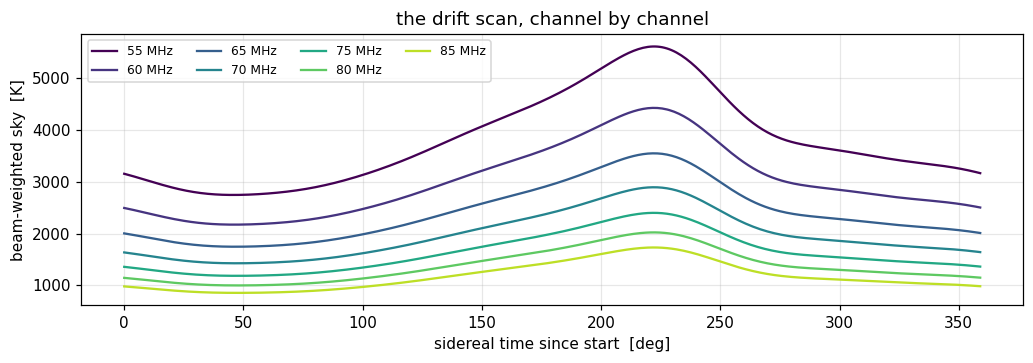

In [3]:
dt_deg = np.unwrap(np.deg2rad(lst)) * 180 / np.pi - lst[0]
fig, ax = plt.subplots(figsize=(9.5, 3.4))
for j, f in enumerate(FREQS):
    ax.plot(dt_deg, tod_sky[:, j], color=COLORS[j], label=f"{f:.0f} MHz")
ax.set(xlabel="sidereal time since start  [deg]", ylabel="beam-weighted sky  [K]", title="the drift scan, channel by channel")
ax.legend(ncol=4, fontsize=8); plt.tight_layout()

## 2. The closed scan solves every mode

With no kernel and every mode up to $M=40$ in the model, the closed scan is exactly determined
(`cond` ≈ 1). The noiseless solve is the **ground truth** for the rest of the notebook.

In [4]:
M_ALL = 40
truth = mmode.solve(tod_sky, window, m_trunc=M_ALL)
d_true = truth.modes                                   # (n_freq, M+1) complex
print(f"cond = {truth.cond:.3f}   residual rms per channel [K] = {truth.residual_rms}")

cond = 1.000   residual rms per channel [K] = [0.041 0.033 0.027 0.022 0.019 0.016 0.014]


### The m-mode spectra

Left: how fast the scan runs out of information — $|d_m|$ falls steeply with $m$ because a 30° beam is a very
low-$\ell$ object. Right: the **spectra** $d_m(\nu)$ themselves, real and imaginary parts, for the lowest modes.
These are the linear components: what a foreground model has to reproduce, channel by channel.

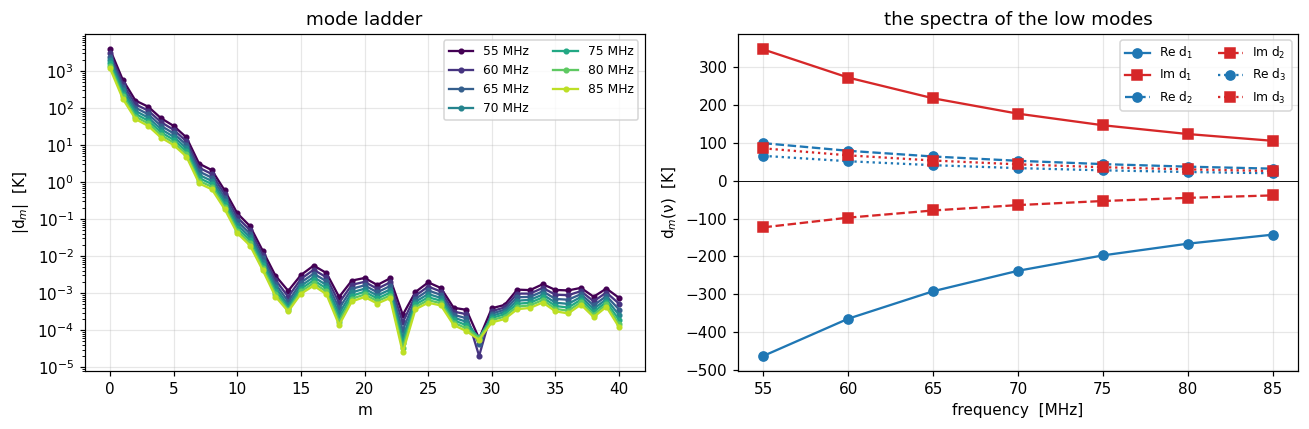

In [5]:
m_axis = np.arange(M_ALL + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for j, f in enumerate(FREQS):
    axes[0].semilogy(m_axis, np.abs(d_true[j]), ".-", color=COLORS[j], label=f"{f:.0f} MHz")
axes[0].set(xlabel="m", ylabel="|d$_m$|  [K]", title="mode ladder"); axes[0].legend(fontsize=8, ncol=2)
for mm, ls in ((1, "-"), (2, "--"), (3, ":")):
    axes[1].plot(FREQS, d_true[:, mm].real, "o" + ls, color="C0", label=f"Re d$_{mm}$")
    axes[1].plot(FREQS, d_true[:, mm].imag, "s" + ls, color="C3", label=f"Im d$_{mm}$")
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set(xlabel="frequency  [MHz]", ylabel="d$_m$(ν)  [K]", title="the spectra of the low modes")
axes[1].legend(fontsize=8, ncol=2); plt.tight_layout()

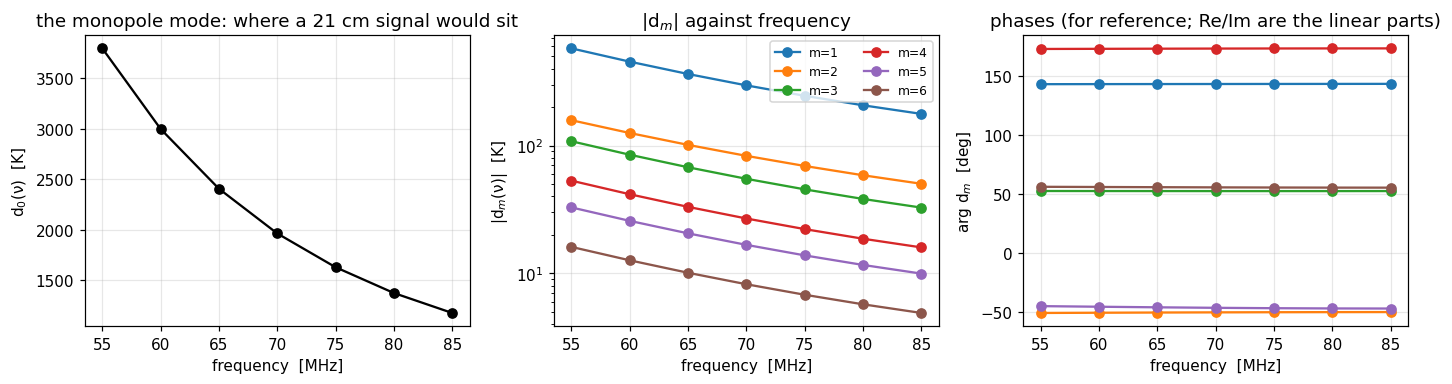

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].plot(FREQS, d_true[:, 0].real, "o-", color="k")
axes[0].set(xlabel="frequency  [MHz]", ylabel="d$_0$(ν)  [K]", title="the monopole mode: where a 21 cm signal would sit")
for mm in range(1, 7):
    axes[1].plot(FREQS, np.abs(d_true[:, mm]), "o-", label=f"m={mm}")
axes[1].set(xlabel="frequency  [MHz]", ylabel="|d$_m$(ν)|  [K]", yscale="log", title="|d$_m$| against frequency")
axes[1].legend(fontsize=8, ncol=2)
ph = np.degrees(np.angle(d_true[:, 1:7]))
for mm in range(6):
    axes[2].plot(FREQS, ph[:, mm], "o-", label=f"m={mm + 1}")
axes[2].set(xlabel="frequency  [MHz]", ylabel="arg d$_m$  [deg]", title="phases (for reference; Re/Im are the linear parts)")
plt.tight_layout()

### Noise propagates as reported

Add white noise of 2 K per sample and solve again. `std_d0()` and `std_mode(m)` come from the sandwich
covariance; the pulls $(\hat d-d)/\sigma$ over every mode and channel should be unit-normal.

pull rms over 567 numbers: 1.04   (1.0 if the errors are right)


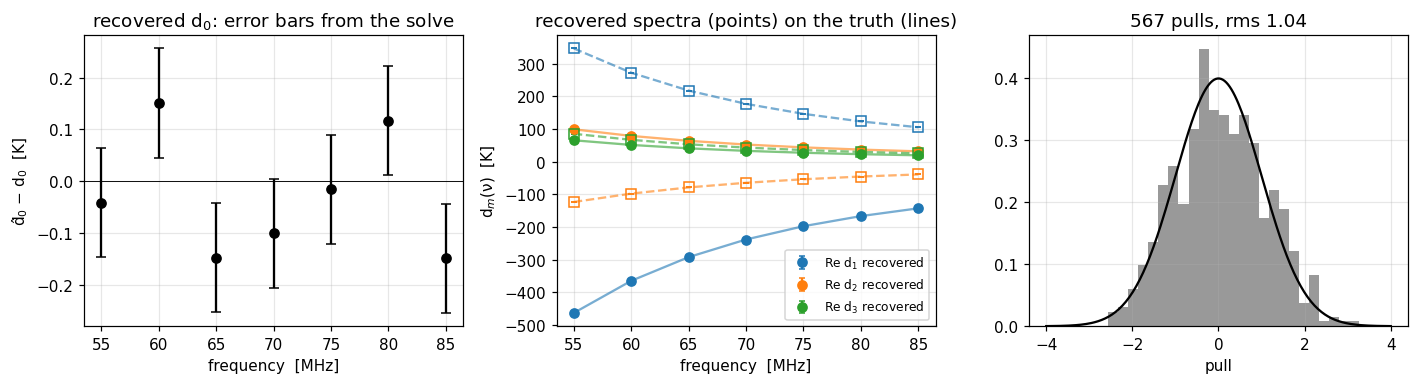

In [7]:
SIGMA = 2.0                                            # K per sample
rng = np.random.default_rng(1)
tod_noisy = tod_sky + rng.normal(0, SIGMA, tod_sky.shape)

est = mmode.solve(tod_noisy, window, m_trunc=M_ALL, sigma=SIGMA)
pulls = []
for j in range(FREQS.size):
    pulls.append((est.d0[j] - d_true[j, 0].real) / est.std_d0()[j])
    for mm in range(1, M_ALL + 1):
        s = est.std_mode(mm)[j]
        pulls += [(est.modes[j, mm].real - d_true[j, mm].real) / s[0],
                  (est.modes[j, mm].imag - d_true[j, mm].imag) / s[1]]
pulls = np.array(pulls)
print(f"pull rms over {pulls.size} numbers: {pulls.std():.2f}   (1.0 if the errors are right)")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].errorbar(FREQS, est.d0 - d_true[:, 0].real, yerr=est.std_d0(), fmt="o", color="k", capsize=3)
axes[0].axhline(0, color="k", lw=0.6); axes[0].set(xlabel="frequency  [MHz]", ylabel="d̂$_0$ − d$_0$  [K]", title="recovered d$_0$: error bars from the solve")
for mm, c in ((1, "C0"), (2, "C1"), (3, "C2")):
    s = est.std_mode(mm)
    axes[1].errorbar(FREQS, est.modes[:, mm].real, yerr=s[:, 0], fmt="o", color=c, capsize=2, label=f"Re d$_{mm}$ recovered")
    axes[1].plot(FREQS, d_true[:, mm].real, "-", color=c, alpha=0.6)
    axes[1].errorbar(FREQS, est.modes[:, mm].imag, yerr=s[:, 1], fmt="s", color=c, capsize=2, mfc="none")
    axes[1].plot(FREQS, d_true[:, mm].imag, "--", color=c, alpha=0.6)
axes[1].set(xlabel="frequency  [MHz]", ylabel="d$_m$(ν)  [K]", title="recovered spectra (points) on the truth (lines)")
axes[1].legend(fontsize=8)
axes[2].hist(pulls, bins=25, density=True, color="0.6")
x = np.linspace(-4, 4, 200); axes[2].plot(x, np.exp(-x**2 / 2) / np.sqrt(2 * np.pi), "k")
axes[2].set(xlabel="pull", title=f"{pulls.size} pulls, rms {pulls.std():.2f}")
plt.tight_layout()

## 3. A 7 h arc cannot separate the low modes

Take the first 7 h of the same scan. The solve runs, but the design is degenerate — `1, cos t, cos 2t` are
nearly the same parabola over 105° — and the error bar on $d_0$ is enormous. That number is the honest answer;
the estimate itself is meaningless. `noise_amplification` is the same quantity in extended precision.

7 h arc: 106 samples, span 105.3 deg, coverage 0.30, Rayleigh width 3.42 in m, Shannon number at M=8: 5.0 of 17


cond = 6.4e+09
d_0 estimate at 55 MHz: -5.628e+08 K   truth 3797.4 K   reported 1-sigma 3.370e+08 K   = sigma x amplification 3.370e+08 K


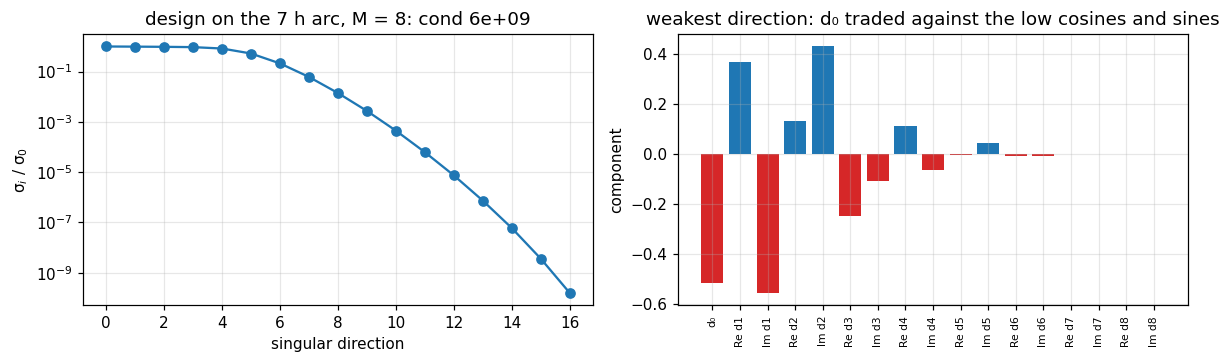

In [8]:
n7 = int(round(7 * 3600 / (SIDEREAL_DAY / N_T))) + 1
arc7 = mmode.LSTWindow(lst[:n7], t_ref_deg=lst[0])
print(f"7 h arc: {arc7.n} samples, span {arc7.span_deg:.1f} deg, coverage {arc7.coverage:.2f}, "
      f"Rayleigh width {arc7.rayleigh:.2f} in m, Shannon number at M=8: {arc7.shannon_number(8):.1f} of 17")

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    res7 = mmode.solve(tod_noisy[:n7], arc7, m_trunc=8, sigma=SIGMA)
    amp = mmode.noise_amplification(arc7, 8)
print("warning:", str(caught[0].message)[:70], "...")
print(f"cond = {res7.cond:.1e}")
print(f"d_0 estimate at {FREQS[0]:.0f} MHz: {res7.d0[0]:.3e} K   truth {d_true[0, 0].real:.1f} K   "
      f"reported 1-sigma {res7.std_d0()[0]:.3e} K   = sigma x amplification {SIGMA * amp:.3e} K")

e7 = mmode.design_matrix(arc7, 8)
sv = np.linalg.svd(e7 / np.linalg.norm(e7, axis=0), compute_uv=False)
weak = np.linalg.svd(e7 / np.linalg.norm(e7, axis=0))[2][-1]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].semilogy(np.arange(sv.size), sv / sv[0], "o-")
axes[0].set(xlabel="singular direction", ylabel="σ$_i$ / σ$_0$", title=f"design on the 7 h arc, M = 8: cond {res7.cond:.0e}")
labels = ["d₀"] + [f"{p} d{m}" for m in range(1, 9) for p in ("Re", "Im")]
axes[1].bar(np.arange(weak.size), weak, color=np.where(weak > 0, "C0", "C3"))
axes[1].set_xticks(np.arange(weak.size)); axes[1].set_xticklabels(labels, rotation=90, fontsize=7)
axes[1].set(title="weakest direction: d₀ traded against the low cosines and sines", ylabel="component")
plt.tight_layout()

## 4. Stacking nights closes the circle

The same night-time window drifts by 0.986° a day in sidereal time. `LSTWindow.stacked_nights` bins the visits
and carries the counts as weights. Data on that window are synthesised from the truth with noise scaled by
$1/\sqrt{w}$; the error on $d_0$ collapses once the circle closes, at about 260 nights.

 nights  LST covered  closed       cond   sigma(d_0)   |error|
    120         224°   False    7.3e+15    4.32e+13 K 2.06e+13 K
    160         263°   False    1.7e+15    4.86e+12 K 4.13e+12 K
    200         302°   False    7.5e+08     1.9e+06 K 1.24e+06 K
    220         322°   False    6.2e+05    1.41e+03 K      325 K
    240         342°   False    7.4e+02         1.4 K     1.51 K
    250         352°   False    3.8e+01      0.0619 K   0.0747 K
    255         357°   False    1.2e+01      0.0236 K   0.0203 K
    260         360°    True    5.7e+00      0.0171 K  0.00505 K
    280         360°    True    2.3e+00      0.0132 K 0.000286 K
    300         360°    True    1.6e+00      0.0119 K  0.00233 K
    365         360°    True    1.0e+00      0.0102 K  0.00224 K


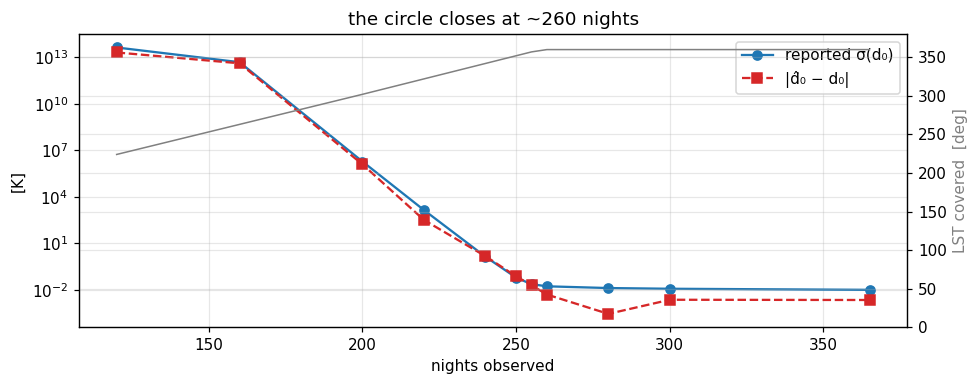

In [9]:
nights_grid = [120, 160, 200, 220, 240, 250, 255, 260, 280, 300, 365]
rows = []
for nights in nights_grid:
    win = mmode.LSTWindow.stacked_nights(nights, lst[0], 105.0, cadence_s=240.0, t_ref_deg=lst[0])
    y = mmode.synthesise(win, d_true) + rng.normal(0, SIGMA, (win.n, FREQS.size)) / np.sqrt(win.weights)[:, None]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r = mmode.solve(y, win, m_trunc=M_ALL, sigma=SIGMA)
    rows.append((nights, win.coverage * 360, win.closed, r.cond, r.std_d0()[0], abs(r.d0[0] - d_true[0, 0].real)))
print(f"{'nights':>7s}{'LST covered':>13s}{'closed':>8s}{'cond':>11s}{'sigma(d_0)':>13s}{'|error|':>10s}")
for n_, c, cl, cond, s, e in rows:
    print(f"{n_:7d}{c:12.0f}°{str(cl):>8s}{cond:11.1e}{s:12.3g} K{e:9.3g} K")

rows = np.array([(r[0], r[1], r[4], r[5]) for r in rows])
fig, ax1 = plt.subplots(figsize=(9, 3.6))
ax1.semilogy(rows[:, 0], rows[:, 2], "o-", color="C0", label="reported σ(d₀)")
ax1.semilogy(rows[:, 0], rows[:, 3], "s--", color="C3", label="|d̂₀ − d₀|")
ax1.set(xlabel="nights observed", ylabel="[K]", title="the circle closes at ~260 nights")
ax1.legend(loc="upper right")
ax2 = ax1.twinx(); ax2.plot(rows[:, 0], rows[:, 1], "-", color="0.5", lw=1)
ax2.set_ylabel("LST covered  [deg]", color="0.5"); ax2.set_ylim(0, 380)
plt.tight_layout()

## 5. Smoothing along LST on a partial arc: the trade

On a 300° arc, smoothing with a DPSS kernel makes a *low* truncation exact up to what the kernel's transfer
$K(m)$ lets through — the sky's own modes above $M$ would otherwise be attributed to the ones below.
The estimator is ordinary least squares on the smoothed data (generalised least squares with the kernel's own
covariance would divide $K(m)$ back out). But every kernel discards half its length at each end of an open arc,
and a shorter arc is worse conditioned. The table and figure show both effects at once for $M=8$:
`leakage_bound` is the worst-case bias from the modes above $M$ given the envelope $|d_m|$ (here from the truth),
`sigma(d_0)` the noise.

kernel                 band edge  valid      cond  sigma(d_0)  |d_0 bias|     bound
none                           -    300   2.4e+01     0.891 K      3.41 K    4.51 K
dpss(L=21, NW=2)            34.2    280   1.0e+02      2.53 K      15.5 K    15.7 K
dpss(L=41, NW=2)            17.5    260   4.7e+02      5.22 K      30.1 K    29.9 K
dpss(L=61, NW=2)            11.8    240   2.4e+03      5.06 K      26.4 K    28.8 K
dpss(L=81, NW=2)             8.9    220   1.3e+04      1.94 K       2.3 K    6.62 K


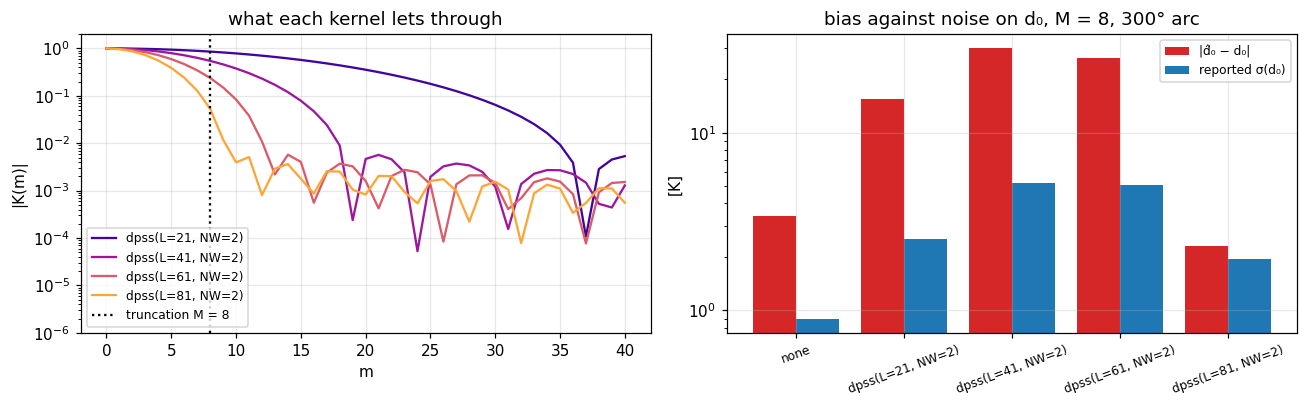

In [10]:
n300 = int(round(300.0 / window.cadence_deg)) + 1
arc300 = mmode.LSTWindow(lst[:n300], t_ref_deg=lst[0])
M_TR = 8
envelope = np.abs(d_true).max(axis=0)
kernels = [(None, None)] + [(mmode.dpss_kernel(L, 2.0), 2.0) for L in (21, 41, 61, 81)]

table = []
print(f"{'kernel':22s}{'band edge':>10s}{'valid':>7s}{'cond':>10s}{'sigma(d_0)':>12s}{'|d_0 bias|':>12s}{'bound':>10s}")
for kern, nw in kernels:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r = mmode.solve(tod_noisy[:n300], arc300, m_trunc=M_TR, kernel=kern, sigma=SIGMA)
        bound = mmode.leakage_bound(arc300, M_TR, envelope, kernel=kern)
    edge = np.nan if kern is None else kern.band_edge(arc300, nw)
    bias = abs(r.d0[0] - d_true[0, 0].real)
    table.append((r.kernel, edge, r.n_valid, r.cond, r.std_d0()[0], bias, bound))
    print(f"{r.kernel:22s}{('-' if kern is None else f'{edge:.1f}'):>10s}{r.n_valid:7d}{r.cond:10.1e}"
          f"{r.std_d0()[0]:10.3g} K{bias:10.3g} K{bound:8.3g} K")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
mm = np.arange(0, 41)
for (kern, nw), c in zip(kernels[1:], plt.cm.plasma(np.linspace(0.1, 0.8, 4))):
    axes[0].semilogy(mm, np.abs(kern.transfer(arc300, 40)), "-", color=c, label=kern.label)
axes[0].axvline(M_TR, color="k", ls=":", label=f"truncation M = {M_TR}")
axes[0].set(xlabel="m", ylabel="|K(m)|", ylim=(1e-6, 2), title="what each kernel lets through")
axes[0].legend(fontsize=8)
names = [t[0] for t in table]; x = np.arange(len(table))
axes[1].bar(x - 0.2, [t[5] for t in table], 0.4, label="|d̂₀ − d₀|", color="C3")
axes[1].bar(x + 0.2, [t[4] for t in table], 0.4, label="reported σ(d₀)", color="C0")
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20, fontsize=8)
axes[1].set(ylabel="[K]", yscale="log", title="bias against noise on d₀, M = 8, 300° arc"); axes[1].legend(fontsize=8)
plt.tight_layout()

**Reading it.** A kernel whose band edge sits *above* the truncation suppresses nothing the model does not
already carry, and only pays: fewer valid samples, worse conditioning, larger noise and a bias five to ten times
larger than with no kernel at all. Only the kernel matched to the truncation (L = 81, edge ≈ 9) earns its keep —
its realised bias on $d_0$ comes down to the level of its own noise — and even then at twice the noise of the
unsmoothed solve and a wider bound. On a closed scan none of this arises: every mode is orthogonal and the
kernel is unnecessary.

## 6. Exact posterior samples with bayesmith (optional)

Instead of truncating, give every mode a Gaussian prior of width `envelope[m]` and observe the raw samples.
bayesmith certifies the model as linear-Gaussian and draws exact posterior samples; the credible band on
$d_0(\nu)$ comes from them. Skipped if bayesmith is not installed (`pip install limTOD[mmode-bayes]`).

  MHz     truth  posterior   68% low  68% high  least sq    +/-
   55  3797.436   3797.435  3797.366  3797.530  3797.394  0.106
   60  2998.949   2999.079  2998.974  2999.208  2999.100  0.106
   65  2406.780   2406.639  2406.524  2406.755  2406.632  0.106
   70  1963.954   1963.846  1963.765  1963.941  1963.853  0.106
   75  1629.337   1629.336  1629.190  1629.440  1629.321  0.106
   80  1373.634   1373.751  1373.666  1373.827  1373.750  0.106
   85  1176.021   1175.872  1175.771  1175.940  1175.872  0.106


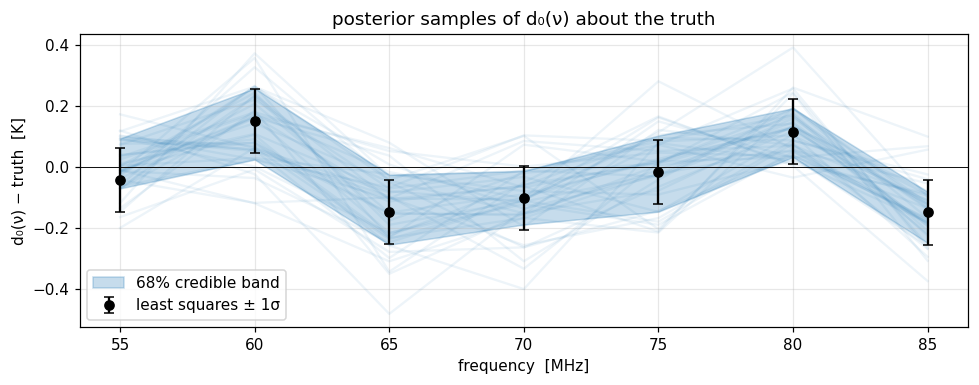

In [11]:
try:
    from limTOD.mmode.bayes import posterior_samples
    M_B = 12                                         # keep the demo quick
    env = 2 * np.abs(d_true[:, :M_B + 1]).max(axis=0) + 1e-3
    post = posterior_samples(tod_noisy, window, mmax=M_B, envelope=env, sigma=SIGMA, n_draws=40, seed=2)
    lo, hi = post.d0_interval(0.68)
    ls = mmode.solve(tod_noisy, window, m_trunc=M_B, sigma=SIGMA)
    print(f"{'MHz':>5s}{'truth':>10s}{'posterior':>11s}{'68% low':>10s}{'68% high':>10s}{'least sq':>10s}{'+/-':>7s}")
    for j, f in enumerate(FREQS):
        print(f"{f:5.0f}{d_true[j, 0].real:10.3f}{post.d0[j]:11.3f}{lo[j]:10.3f}{hi[j]:10.3f}{ls.d0[j]:10.3f}{ls.std_d0()[j]:7.3f}")

    fig, ax = plt.subplots(figsize=(9, 3.6))
    for s in post.samples[:, :, 0].real:
        ax.plot(FREQS, s - d_true[:, 0].real, "-", color="C0", alpha=0.08)
    ax.fill_between(FREQS, lo - d_true[:, 0].real, hi - d_true[:, 0].real, color="C0", alpha=0.25, label="68% credible band")
    ax.errorbar(FREQS, ls.d0 - d_true[:, 0].real, yerr=ls.std_d0(), fmt="ko", capsize=3, label="least squares ± 1σ")
    ax.axhline(0, color="k", lw=0.6)
    ax.set(xlabel="frequency  [MHz]", ylabel="d₀(ν) − truth  [K]", title="posterior samples of d₀(ν) about the truth")
    ax.legend(); plt.tight_layout()
except ImportError as exc:
    print(exc)